

**Ćwiczenie 1. Pierwsza mapa świata**

1. Pobierz dane z zip `Natural Earth` w skali 1:110m z repozytorium NACIS.
2. Wczytaj dane do obiektu `GeoDataFrame`.

---


In [1]:
from pathlib import Path
from urllib.request import urlretrieve

import geopandas as gpd

# 1. Pobranie zipa Natural Earth 1:110m (Admin 0 – Countries) z CDN NACIS
NE_URL = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
zip_path = Path("dane/natural_earth/ne_110m_admin_0_countries.zip")
zip_path.parent.mkdir(parents=True, exist_ok=True)

if not zip_path.exists():
    urlretrieve(NE_URL, zip_path)

# 2. Wczytanie do GeoDataFrame – GeoPandas czyta shapefile bezpośrednio z zipa
world = gpd.read_file(zip_path)

print(type(world))
print("Liczba krajów:", len(world))
print("CRS:", world.crs)
world[["ADMIN", "CONTINENT", "POP_EST", "geometry"]].head()

<class 'geopandas.geodataframe.GeoDataFrame'>
Liczba krajów: 177
CRS: EPSG:4326


,ADMIN,CONTINENT,POP_EST,geometry
0,Fiji,Oceania,889953.0,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,United Republic of Tanzania,Africa,58005463.0,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Western Sahara,Africa,603253.0,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Canada,North America,37589262.0,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,United States of America,North America,328239523.0,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."




**Ćwiczenie 2. Wybrane regiony**

1. Wybierz z ramki dane dotyczące Polski i jej sąsiadów (Niemcy, Czechy, Słowacja, Ukraina, Białoruś, Litwa).
2. Stwórz mapę pokazującą tylko ten wycinek Europy.
3. Pokoloruj kraje na jeden kolor i dodaj tytuł mapy.

---

Wybrane kraje: ['Belarus', 'Czechia', 'Germany', 'Lithuania', 'Poland', 'Slovakia', 'Ukraine']


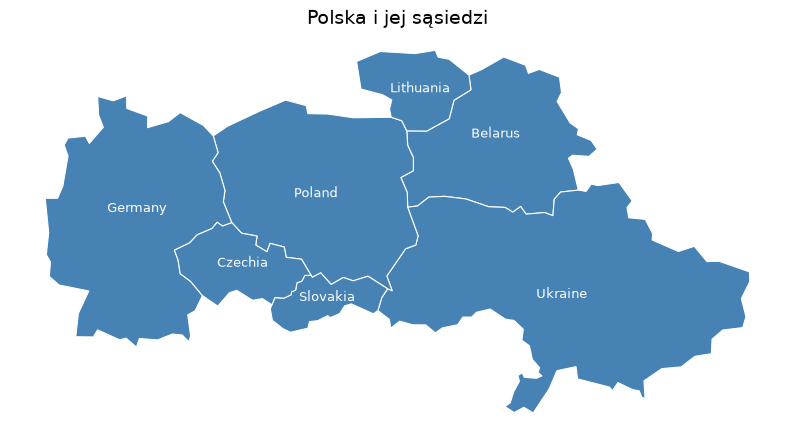

In [2]:
import matplotlib.pyplot as plt

# 1. Polska i sąsiedzi – nazwy jak w kolumnie NAME w Natural Earth
kraje = ["Poland", "Germany", "Czechia", "Slovakia", "Ukraine", "Belarus", "Lithuania"]
region = world[world["NAME"].isin(kraje)]
print("Wybrane kraje:", sorted(region["NAME"]))

# 2–3. Mapa tylko tego wycinka Europy, jeden kolor, tytuł
ax = region.plot(color="steelblue", edgecolor="white", linewidth=0.8, figsize=(10, 8))

for _, row in region.iterrows():
    punkt = row.geometry.representative_point()
    ax.annotate(row["NAME"], xy=(punkt.x, punkt.y), ha="center", fontsize=9, color="white")

ax.set_title("Polska i jej sąsiedzi", fontsize=14)
ax.set_axis_off()
plt.show()


**Ćwiczenie 3. Usunięcie zbędnych danych**

1. Usuń z ramki dane dotyczące Antarktyki i terytoriów „Fr. S. Antarctic Lands”.
2. Ponownie narysuj mapę kontynentów.
3. Porównaj wynik z mapą z poprzedniego ćwiczenia.

---

Liczba krajów przed usunięciem: 177
Liczba krajów po usunięciu: 175


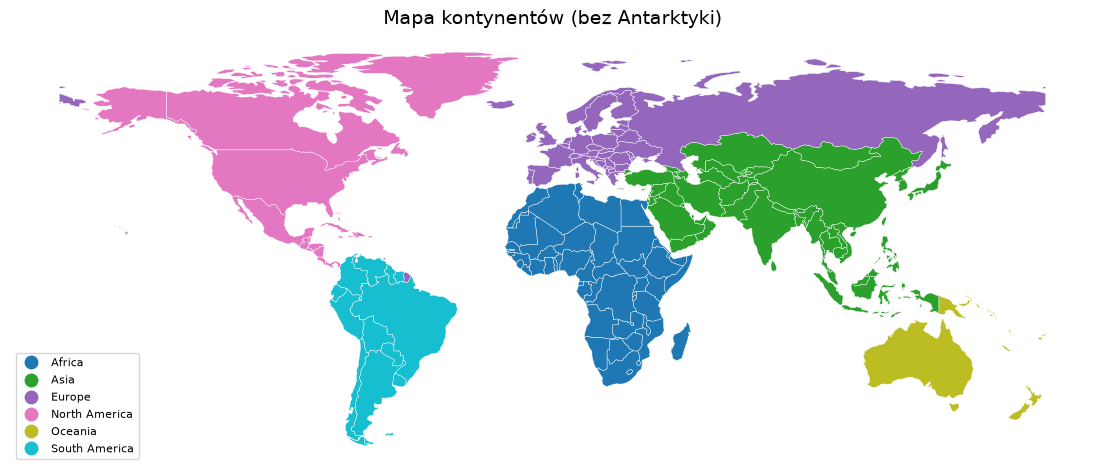

In [3]:
import matplotlib.pyplot as plt

# 1. Usunięcie Antarktyki i Francuskich Terytoriów Południowych i Antarktycznych
world_bez_antarktydy = world[~world["NAME"].isin(["Antarctica", "Fr. S. Antarctic Lands"])]

print("Liczba krajów przed usunięciem:", len(world))
print("Liczba krajów po usunięciu:", len(world_bez_antarktydy))

# 2. Ponowne narysowanie mapy kontynentów (bez Antarktyki)
ax = world_bez_antarktydy.plot(
    column="CONTINENT",
    legend=True,
    figsize=(14, 8),
    edgecolor="white",
    linewidth=0.3,
    legend_kwds={"loc": "lower left", "fontsize": 8},
)
ax.set_title("Mapa kontynentów (bez Antarktyki)", fontsize=14)
ax.set_axis_off()
plt.show()

# 3. Porównanie z mapą z poprzedniego ćwiczenia
# Poprzednia mapa (Ćwiczenie 2) pokazywała tylko niewielki wycinek Europy
# (Polskę i sąsiadów). Tutaj widać cały świat pokolorowany wg kontynentu -
# po usunięciu Antarktyki zniknął duży biały obszar na południu wykresu,
# dzięki czemu pozostałe kontynenty (zwłaszcza Ameryka Południowa, Afryka
# i Oceania) są proporcjonalnie większe i lepiej widoczne na mapie.


**Ćwiczenie 4. Zmiana układu odniesienia**

1. Sprawdź domyślny układ odniesienia (`crs`) w danych.
2. Zmień układ na `EPSG:3395` (Mercator).
3. Narysuj mapę i zwróć uwagę, jak zmieniły się proporcje powierzchni państw (np. Grenlandii).

---

## Zadanie z adresowo

In [4]:
import geopandas as gpd

url = "https://raw.githubusercontent.com/marcin119a/data/refs/heads/main/warszawa_adresowo_ceny.geojson"
gdf = gpd.read_file(url)

gdf.head()



,cartodb_id,name,locality,mean_price,median_price,min_price,max_price,mean_price_sqm,offers_count,mean_area,mean_rooms,owner_type_mode,locality_clean,geometry
0,1,Warszawa,Warszawa,1.053227e+06,780000.0,440000.0,2290000.0,19075.769231,13,53.615385,2.230769,Oferta biura nieruchomości,Warszawa,"MULTIPOLYGON (((21.02753 52.36513, 21.02539 52..."
1,22,Ochota,Warszawa Ochota,8.729095e+05,765000.0,380000.0,2499000.0,19456.186047,43,45.441860,2.093023,Bez pośredników,Ochota,"MULTIPOLYGON (((21.00152 52.22807, 20.99059 52..."
2,25,Rembertów,Warszawa Rembertów,7.772000e+05,649000.0,550000.0,1380000.0,13817.400000,15,59.578947,2.736842,Bez pośredników,Rembertów,"MULTIPOLYGON (((21.13242 52.23909, 21.13313 52..."
3,2,Bemowo,Warszawa Bemowo,9.881754e+05,890000.0,450000.0,2400000.0,17690.987342,79,56.011364,2.556818,Bez pośredników,Bemowo,"MULTIPOLYGON (((20.87309 52.21666, 20.87307 52..."
4,19,Białołęka,Warszawa Białołęka,8.174858e+05,735000.0,192000.0,2600000.0,14770.938776,98,55.500000,2.480392,Bez pośredników,Białołęka,"MULTIPOLYGON (((20.99622 52.28734, 20.99782 52..."


**Zad 1. Kartogram średnich cen mieszkań w dzielnicach Warszawy**

Zadanie: Stwórz mapę typu choropleth na podstawie kolumny mean_price, wizualizując różnice cen między dzielnicami.
Cel: Przećwiczyć podstawową wizualizację danych przestrzennych i zobaczyć przestrzenną strukturę cen.

**Zad 2. Kartogram mediany cen**

Zadanie: Wygeneruj kartogram, który pokazuje medianę median_price dla każdej dzielnicy, używając skali kolorów podkreślającej kontrasty.
Cel: Zrozumieć, jak różne agregacje wpływają na wnioski przestrzenne.

**Zad 3. Kartogram aktywności rynku (liczba ofert)**

Zadanie: Za pomocą kolumny offers_count stwórz kartogram pokazujący, w których dzielnicach rynek mieszkań jest najbardziej aktywny.
Cel: Przećwiczyć wizualizację intensywności zjawiska w przestrzeni i interpretację rozkładu ofert.